In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("C://Users//email//Downloads//TSX Merged.csv")
data = df.drop_duplicates()  

C:\Users\email\AppData\Local\Temp\ipykernel_27748\3193827917.py:1: DtypeWarning: Columns (93,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("C://Users//email//Downloads//TSX Merged.csv")


C:\Users\email\AppData\Local\Temp\ipykernel_27748\259855531.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')


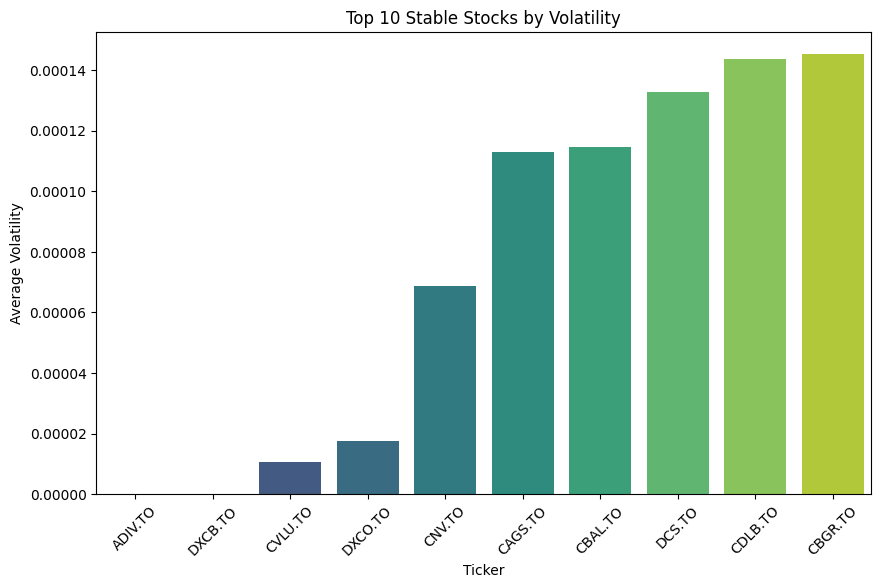

C:\Users\email\AppData\Local\Temp\ipykernel_27748\259855531.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')


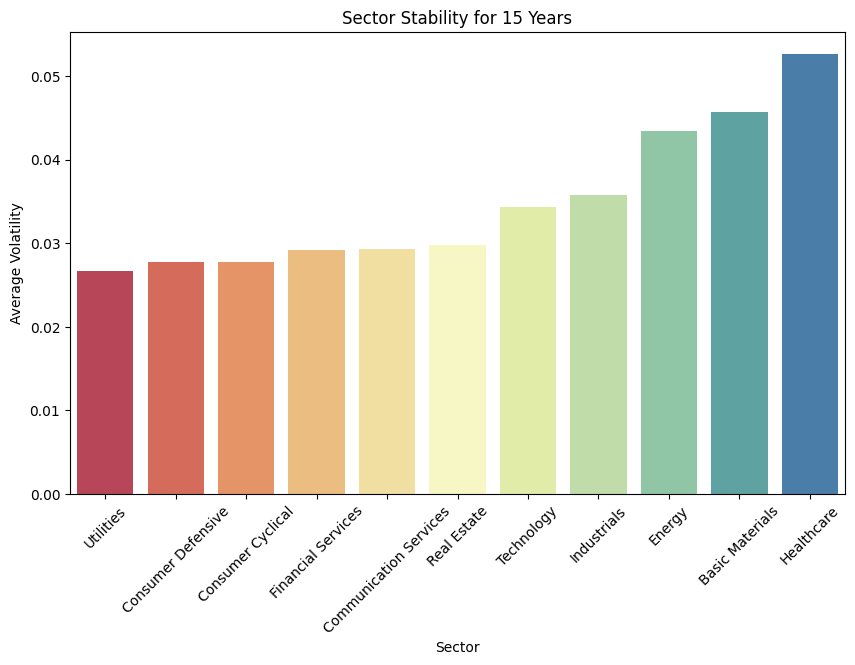

In [7]:
# Define functions to generate insights

def analyze_stock_stability(data):
    """Analyze stock stability and risk."""
    data['price_range'] = data['high'] - data['low']  # Calculate price range
    data['volatility'] = data['price_range'] / data['close']  # Calculate volatility as percentage
    stable_stocks = data.groupby('tic').agg({
        'volatility': 'mean',
        'beta': 'mean',
    }).sort_values(by='volatility', ascending=True).head(10)
    return stable_stocks

def analyze_sector_stability(data, periods):
    """Identify the most stable sector for different investment periods."""
    data['price_range'] = data['high'] - data['low']
    data['volatility'] = data['price_range'] / data['close']
    
    stable_sectors = {}
    for period in periods:
        # Filter data for the specified period
        period_data = data[data['date'] >= (pd.to_datetime(data['date']).max() - pd.DateOffset(years=period)).strftime('%Y-%m-%d')]
        
        # Group by sector and calculate average volatility
        sector_volatility = period_data.groupby('sector').agg({
            'volatility': 'mean'
        }).sort_values(by='volatility', ascending=True)
        
        stable_sectors[period] = sector_volatility
    
    return stable_sectors

# Visualization functions
def visualize_stability(stable_stocks):
    """Visualize stable stocks."""
    stable_stocks.reset_index(inplace=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')
    plt.title('Top 10 Stable Stocks by Volatility')
    plt.xlabel('Ticker')
    plt.ylabel('Average Volatility')
    plt.xticks(rotation=45)
    plt.show()

def visualize_sector_stability(stable_sectors):
    """Visualize sector stability over different investment periods."""
    for period, sector_data in stable_sectors.items():
        sector_data.reset_index(inplace=True)
        plt.figure(figsize=(10, 6))
        sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')
        plt.title(f'Sector Stability for {period} Years')
        plt.xlabel('Sector')
        plt.ylabel('Average Volatility')
        plt.xticks(rotation=45)
        plt.show()

# Run analyses
stability_insights = analyze_stock_stability(data)
investment_periods = [15]  # Define investment periods in years
sector_stability_insights = analyze_sector_stability(data, investment_periods)

# Visualize results as bar graph
visualize_stability(stability_insights)
visualize_sector_stability(sector_stability_insights)


C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of

            date          close           high        low       open  volume  \
21288 2004-12-01    3726.000000    3780.000000    3618.00    3618.00      15   
21303 2004-12-01      12.962213      18.299999      17.82      17.85  531000   
21342 2004-12-01       1.950000       2.050000       1.95       2.00    1200   
21344 2004-12-01  459000.000000  462000.000000  450000.00  451800.00       1   
21360 2004-12-01       0.707200       1.400000       1.34       1.34  352200   

           tic  day                                  industry      sector  \
21288   APS.TO    2                             Biotechnology  Healthcare   
21303   BHC.TO    2  Drug Manufacturers - Specialty & Generic  Healthcare   
21342   CPH.TO    2  Drug Manufacturers - Specialty & Generic  Healthcare   
21344  CSCI.TO    2                             Biotechnology  Healthcare   
21360   EDT.TO    2                    Diagnostics & Research  Healthcare   

       ...  navPrice  ytdReturn  fundFamily  legalType  

<Figure size 1200x800 with 0 Axes>

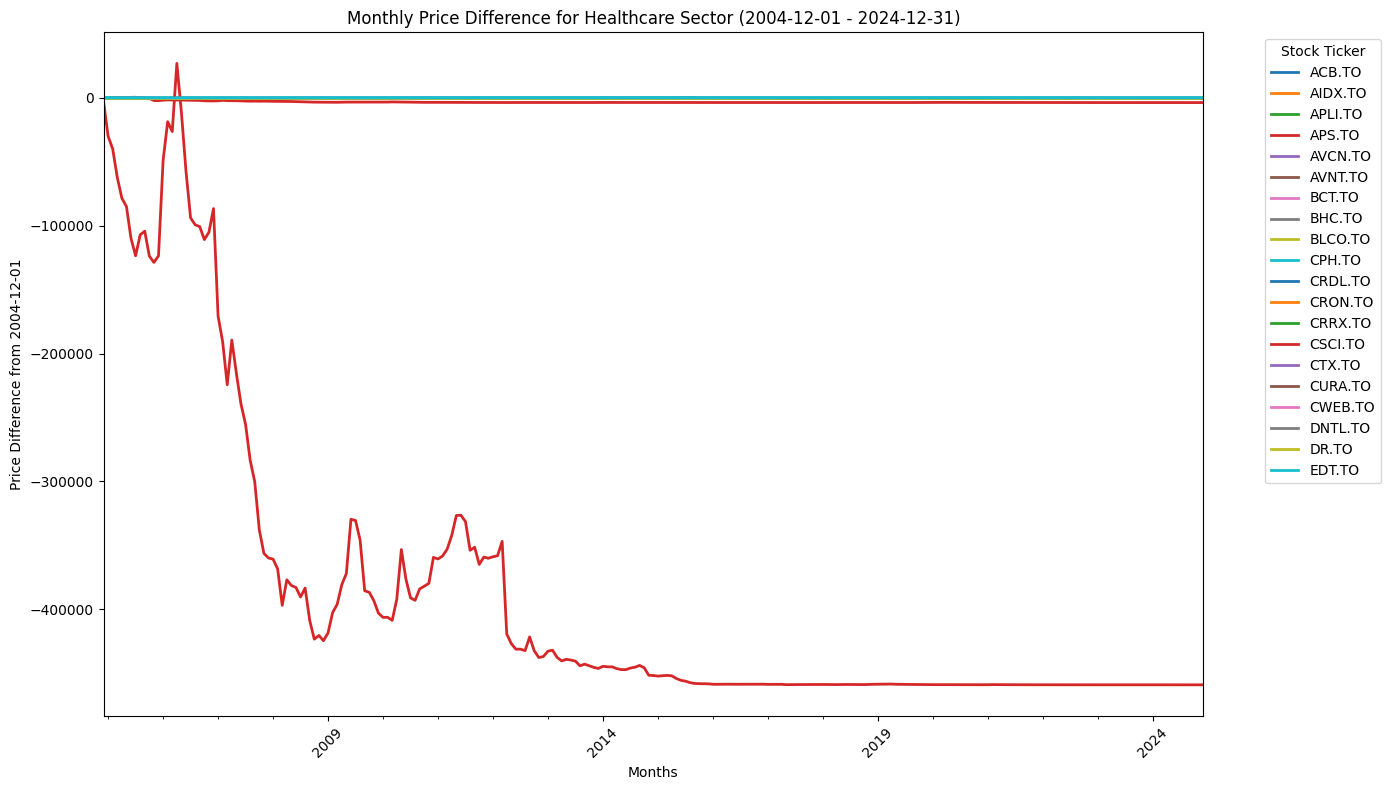

             date      close   high    low   open  volume      tic  day  \
859729 2022-12-01  17.799999  17.90  17.00  17.40  305080   ACB.TO    3   
859742 2022-12-01   0.540000   0.54   0.54   0.54       0  AIDX.TO    3   
859756 2022-12-01   0.050000   0.05   0.05   0.05   19729  APLI.TO    3   
859757 2022-12-01  13.500000  13.65  13.50  13.50     420   APS.TO    3   
859776 2022-12-01   0.320000   0.33   0.32   0.33   43100  AVCN.TO    3   

                                        industry      sector  ...  navPrice  \
859729  Drug Manufacturers - Specialty & Generic  Healthcare  ...       NaN   
859742                   Medical Care Facilities  Healthcare  ...       NaN   
859756                             Biotechnology  Healthcare  ...       NaN   
859757                             Biotechnology  Healthcare  ...       NaN   
859776  Drug Manufacturers - Specialty & Generic  Healthcare  ...       NaN   

        ytdReturn  fundFamily  legalType  yield  threeYearAverageReturn  \

C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
C:\Users\email\AppData\Local\Temp\ipykernel_27748\3845541704.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of

<Figure size 1200x800 with 0 Axes>

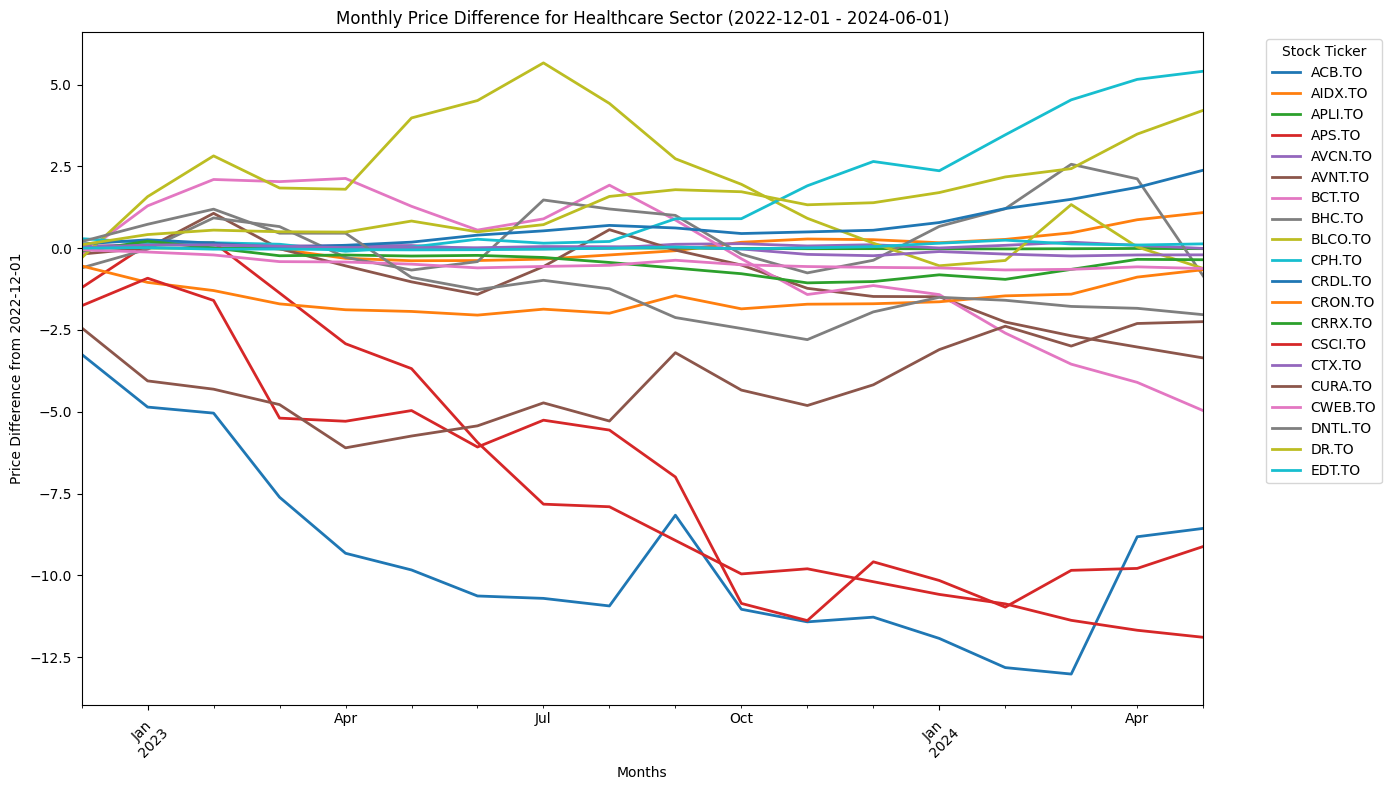

In [8]:
healthcare_data=data[(data['sector']=="Healthcare")] ###&(data['date'] >= '2004-12-01') & (data['date'] <= '2023-06-01')]
healthcare_data.sort_values(by='date')
def calculate_price(startdate,enddate): 
  # Get baseline prices for December 1, 2022
     healthcare_data1=healthcare_data[(healthcare_data['date'] >= startdate) & (healthcare_data['date'] <= enddate)]

     healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
     baseline_prices = (
         healthcare_data1[healthcare_data1['date'] == startdate]
         .groupby('tic')['close']
         .first()
         .to_dict()
         )
     print(healthcare_data1.head())
     # Calculate price difference from baseline
     healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
     healthcare_data1['price_difference'] = healthcare_data1['close'] - healthcare_data1['price_difference']

    # Extract year and month for grouping
     healthcare_data1['year_month'] = healthcare_data1['date'].dt.to_period('M')

    # Aggregate by month for each stock
     monthly_diff = healthcare_data1.groupby(['year_month', 'tic'])['price_difference'].mean().reset_index()

    # Pivot data for line plot
     pivot_data = monthly_diff.pivot(index='year_month', columns='tic', values='price_difference')

    # Ensure numeric data and handle missing values
     pivot_data = pivot_data.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Debugging: Check the structure of pivot_data
     print(pivot_data.head())
     # Plot the line graph
     plt.figure(figsize=(12, 8))
     pivot_data.plot(kind='line', figsize=(14, 8), linewidth=2)
     plt.title('Monthly Price Difference for Healthcare Sector ('+startdate+' - '+enddate+')')
     plt.xlabel('Months')
     plt.ylabel('Price Difference from '+startdate)
     plt.xticks(rotation=45)
     plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
     plt.tight_layout()
     plt.show()

calculate_price('2004-12-01','2024-12-31')
calculate_price('2022-12-01','2024-06-01')


                              shortName              sector  \
tic                                                           
CNQ.TO                  CDN NATURAL RES              Energy   
BMO.TO                 BANK OF MONTREAL  Financial Services   
CM.TO   CANADIAN IMPERIAL BANK OF COMME  Financial Services   
CNR.TO    CANADIAN NATIONAL RAILWAY CO.         Industrials   
ABX.TO         BARRICK GOLD CORPORATION     Basic Materials   
BNS.TO              BANK OF NOVA SCOTIA  Financial Services   

                   industry  
tic                          
CNQ.TO        Oil & Gas E&P  
BMO.TO  Banks - Diversified  
CM.TO   Banks - Diversified  
CNR.TO            Railroads  
ABX.TO                 Gold  
BNS.TO  Banks - Diversified  
Baseline prices: {'CM.TO': 13.90853786468506, 'CNR.TO': 12.21787357330322, 'CNQ.TO': 3.54680871963501, 'ABX.TO': 22.01349639892578, 'BNS.TO': 4.200876235961914, 'BMO.TO': 23.17605590820312}


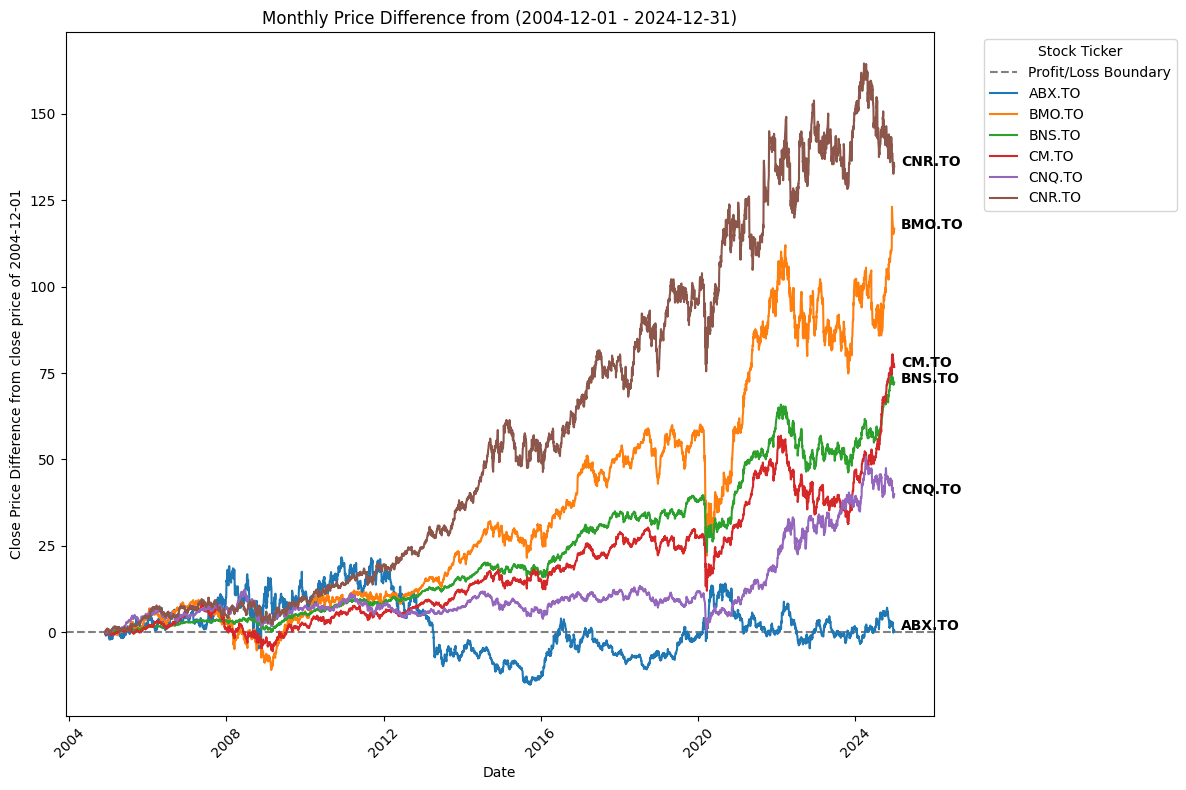

Baseline prices: {'CNQ.TO': 9.831706047058104, 'CNR.TO': 107.5995788574219, 'CM.TO': 35.40581130981445, 'ABX.TO': 30.20410537719727, 'BMO.TO': 56.50580215454102, 'BNS.TO': 34.2382926940918}


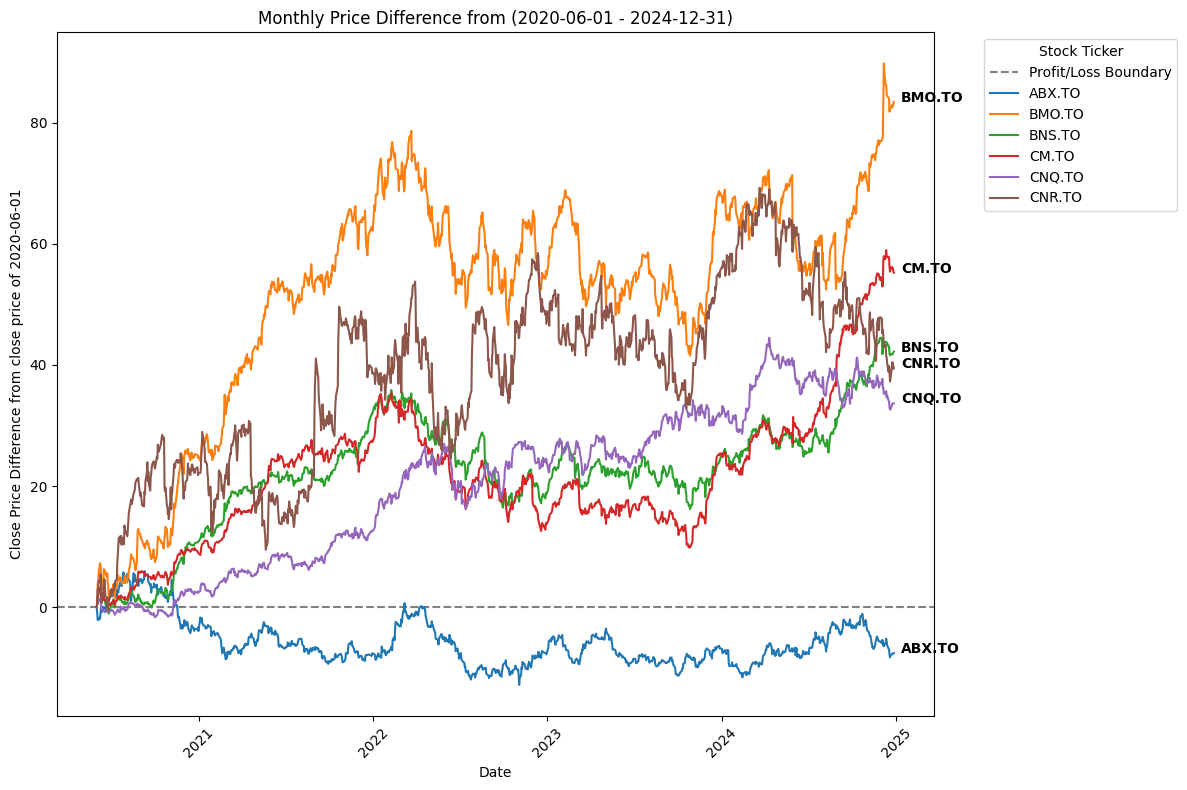

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data  

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Calculate trade value (volume * close price)
analysis_data['trade_value'] = analysis_data['volume'] * analysis_data['close']

# Group by ticker and calculate total trade value over the date range
total_trade_value = analysis_data.groupby('tic')['trade_value'].sum()

# Sort by total trade value in descending order and select top 6
high_trade_value_tickers = total_trade_value.sort_values(ascending=False).head(6).index
ticker_info = analysis_data.set_index('tic')  # Replace with actual DataFrame that contains short_name, sector, industry

high_trade_value_info = ticker_info.loc[high_trade_value_tickers, ['shortName', 'sector', 'industry']].drop_duplicates()

# Print the information
print(high_trade_value_info)

analysis_data = analysis_data[analysis_data['tic'].isin(high_trade_value_tickers)]


def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')
calculate_price('2020-06-01', '2024-12-31')


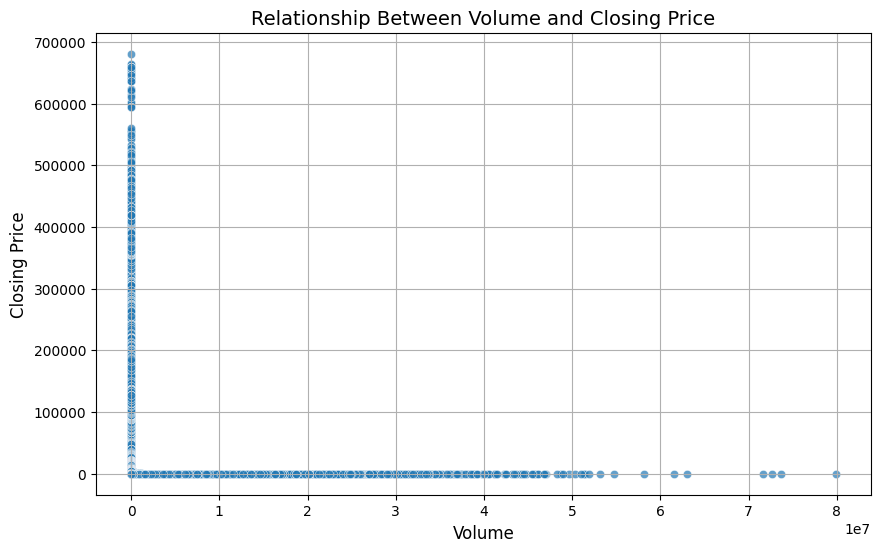

np.float64(-0.011558575871612343)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation between volume and closing price
correlation = data['volume'].corr(data['close'])

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['volume'], y=data['close'], alpha=0.7)
plt.title('Relationship Between Volume and Closing Price', fontsize=14)
plt.xlabel('Volume', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.grid(True)
plt.show()

correlation


Selected Tickers for Visualization:
          tic   trade_value                  sector
3     ABX.TO  4.523340e+11         Basic Materials
72    BCE.TO  3.552376e+11  Communication Services
54    ATD.TO  7.416388e+10       Consumer Cyclical
327   DOL.TO  1.228045e+11      Consumer Defensive
241   CNQ.TO  7.400967e+11                  Energy
100   BMO.TO  5.900755e+11      Financial Services
85    BHC.TO  1.358844e+11              Healthcare
242   CNR.TO  4.939117e+11             Industrials
214  CIGI.TO  2.180222e+10             Real Estate
70     BB.TO  3.009510e+11              Technology
41    AQN.TO  5.389602e+10               Utilities
Baseline prices: {'ABX.TO': 22.01349639892578, 'AQN.TO': 3.003277063369751, 'BMO.TO': 23.17605590820312, 'BB.TO': 35.21666717529297, 'BCE.TO': 9.795751571655272, 'BHC.TO': 12.96221256256104, 'ATD.TO': 2.398196935653687, 'CIGI.TO': 10.95010375976562, 'CNQ.TO': 3.54680871963501, 'CNR.TO': 12.21787357330322}


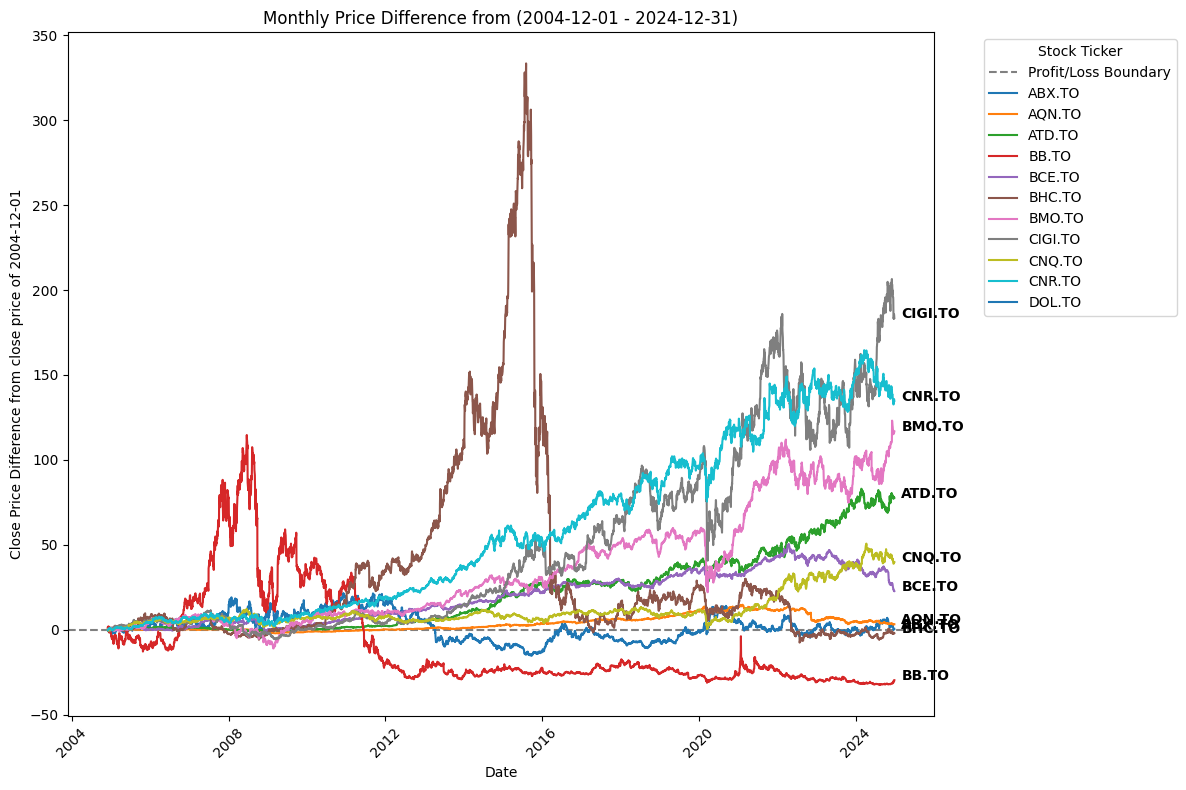

Baseline prices: {'ABX.TO': 30.20410537719727, 'AQN.TO': 14.75610733032227, 'BHC.TO': 26.03000068664551, 'ATD.TO': 40.76572036743164, 'BB.TO': 6.670000076293945, 'BCE.TO': 41.67714309692383, 'BMO.TO': 56.50580215454102, 'CIGI.TO': 70.12066650390625, 'CNQ.TO': 9.831706047058104, 'CNR.TO': 107.5995788574219, 'DOL.TO': 47.42858123779297}


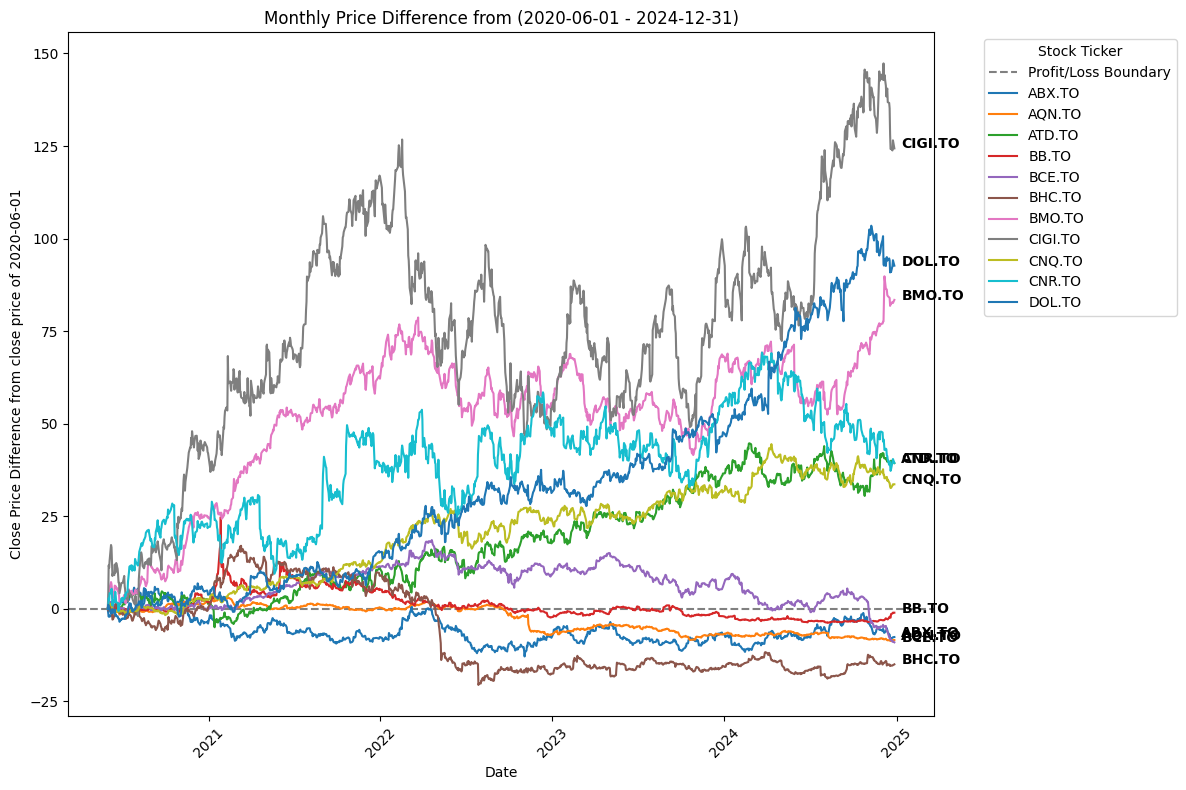

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Calculate trade value (volume * close price)
analysis_data['trade_value'] = analysis_data['volume'] * analysis_data['close']

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()

# Group by ticker and calculate total trade value
total_trade_value = analysis_data.groupby('tic')['trade_value'].sum().reset_index()

# Merge the total trade value with sector information
sector_trade_value = pd.merge(total_trade_value, ticker_info, on='tic')

# Group by sector and select top 2 tickers by trade value
top_tickers_by_sector = (
    sector_trade_value.sort_values(by=['sector', 'trade_value'], ascending=[True, False])
    .groupby('sector')
    .head(1)
)

# Extract the tickers for visualization
high_trade_value_tickers = top_tickers_by_sector['tic'].unique()

# Filter the main dataset for these tickers
analysis_data = analysis_data[analysis_data['tic'].isin(high_trade_value_tickers)]

# Debugging: Print selected tickers
print("Selected Tickers for Visualization:\n", top_tickers_by_sector)

def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')
calculate_price('2020-06-01', '2024-12-31')


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Calculate trade value (volume * close price)
analysis_data['trade_value'] = analysis_data['volume'] * analysis_data['close']

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()

# Group by ticker and calculate total trade value
total_trade_value = analysis_data.groupby('tic')['trade_value'].sum().reset_index()

# Merge the total trade value with sector information
sector_trade_value = pd.merge(total_trade_value, ticker_info, on='tic')

# Group by sector and select top 2 tickers by trade value
top_tickers_by_sector = (
    sector_trade_value.sort_values(by=['sector', 'trade_value'], ascending=[True, False])
    .groupby('sector')
    .head(15)
)

# Extract the tickers for visualization
high_trade_value_tickers = top_tickers_by_sector['tic'].unique()

# Filter the main dataset for these tickers
analysis_data = analysis_data[analysis_data['tic'].isin(high_trade_value_tickers)]

# Debugging: Print selected tickers
print("Selected Tickers for Visualization:\n", top_tickers_by_sector)

# Save the top tickers by sector to an Excel file
top_tickers_by_sector.to_excel("C://Users//email//Downloads//top_tickers_by_sector1.xlsx", index=False)

print("File saved as 'top_tickers_by_sector.xlsx'")



Selected Tickers for Visualization:
          tic   trade_value           sector
3     ABX.TO  4.523340e+11  Basic Materials
15    AEM.TO  2.335959e+11  Basic Materials
397   ELD.TO  9.185825e+10  Basic Materials
125   BTO.TO  4.408156e+10  Basic Materials
17     AG.TO  3.578678e+10  Basic Materials
..       ...           ...              ...
271    CU.TO  4.124688e+10        Utilities
255   CPX.TO  2.530526e+10        Utilities
98    BLX.TO  1.929880e+10        Utilities
79   BEPC.TO  1.453177e+10        Utilities
86   BIPC.TO  9.502808e+09        Utilities

[124 rows x 3 columns]
File saved as 'top_tickers_by_sector.xlsx'


Baseline prices: {'CM.TO': 13.90853786468506, 'CIX.TO': 6.754782676696777, 'CWB.TO': 6.291220664978027, 'BNS.TO': 4.200876235961914, 'BN.TO': 5.119289398193359, 'BMO.TO': 23.17605590820312}


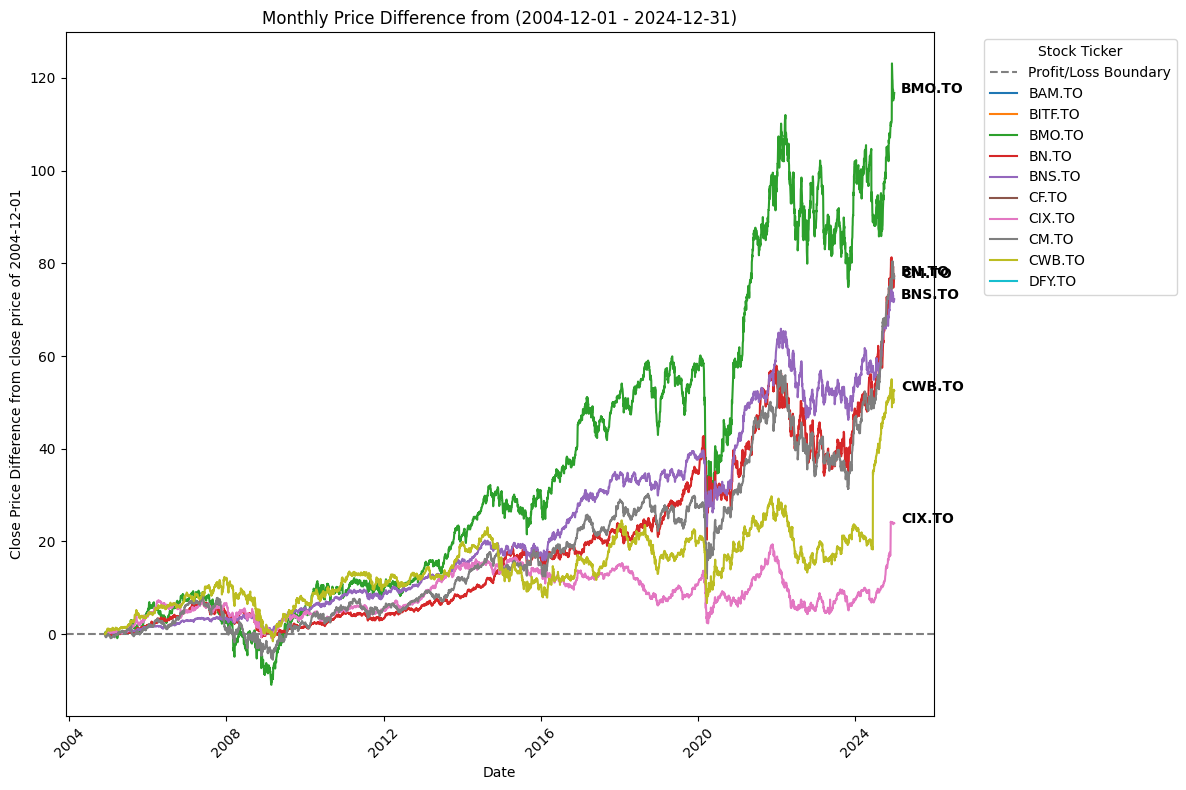

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()

print("finance")

# Define the list of tickers
selected_tickers = [
    'BMO.TO', 'CM.TO', 'BNS.TO', 'BN.TO', 'CIX.TO', 
    'CWB.TO', 'BAM.TO', 'BITF.TO', 'CF.TO', 'DFY.TO'
]

# Filter the dataset
analysis_data = analysis_data[analysis_data['tic'].isin(selected_tickers)]

def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')


Baseline prices: {'ARX.TO': 5.3388352394104, 'ALA.TO': 10.60665035247803, 'BIR.TO': 0.1972078382968903, 'CNQ.TO': 3.54680871963501, 'DML.TO': 4.309999942779541}


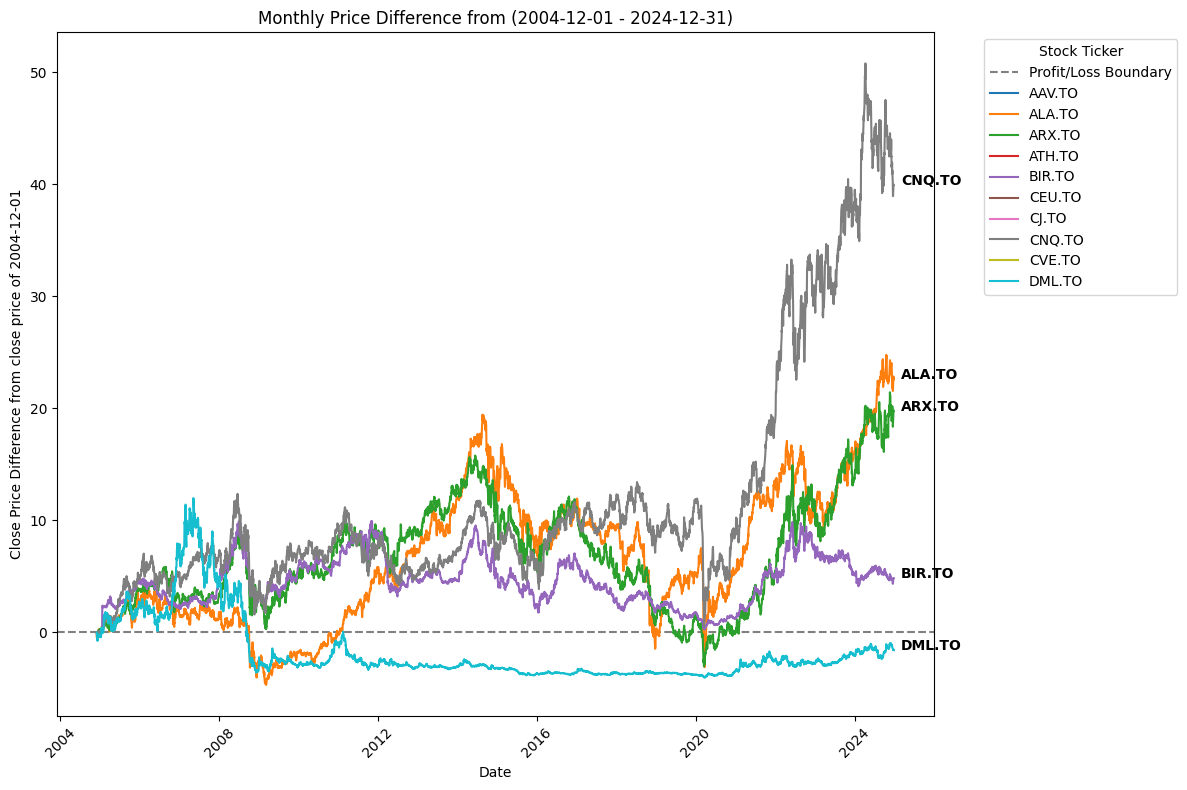

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()

print("energy")

# Define the list of tickers
selected_tickers = [
    'CNQ.TO',
'CVE.TO',
'ARX.TO',
'ALA.TO',
'ATH.TO',
'BIR.TO',
'DML.TO',
'AAV.TO',
'CEU.TO',
'CJ.TO'


]

# Filter the dataset
analysis_data = analysis_data[analysis_data['tic'].isin(selected_tickers)]

def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')


Baseline prices: {'CP.TO': 6.104618549346924, 'CNR.TO': 12.21787357330322, 'ARE.TO': 3.661327362060547, 'ATS.TO': 10.5, 'BLDP.TO': 7.900000095367432, 'BDT.TO': 2.439831018447876}


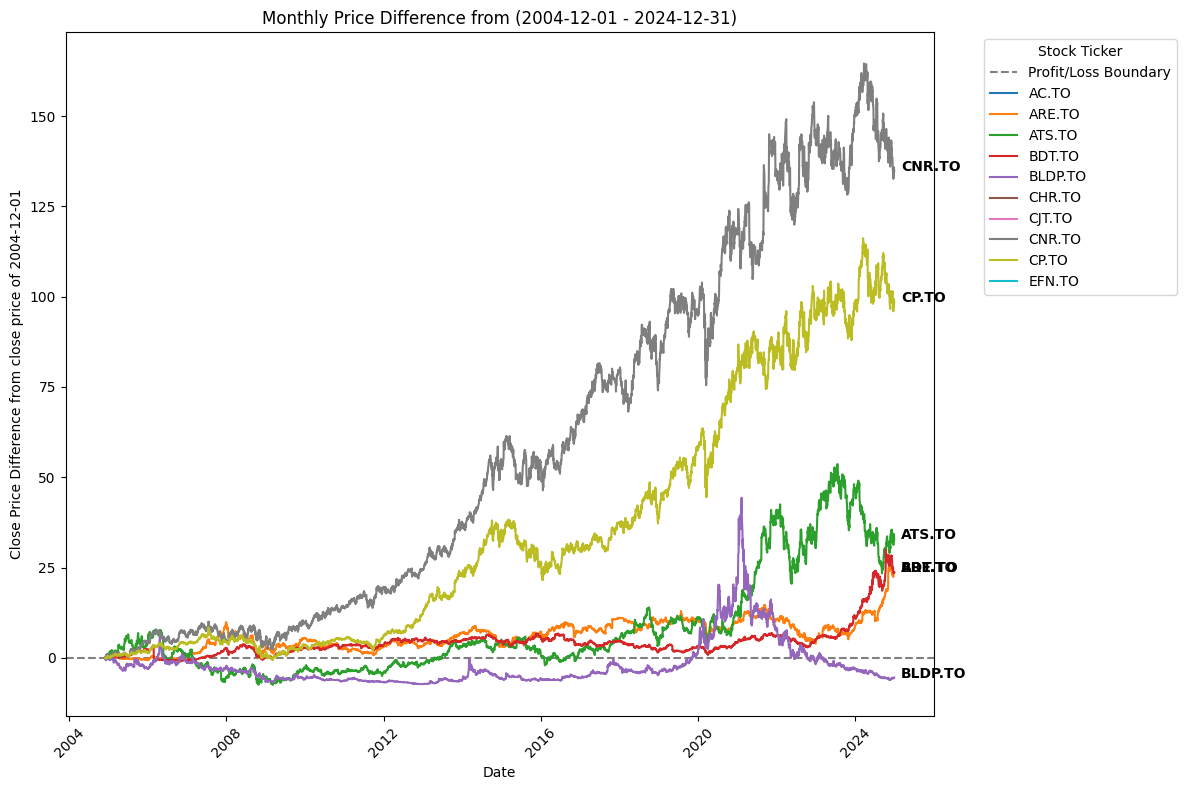

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()

print("industrial")

# Define the list of tickers
selected_tickers = [
    'CNR.TO',
'CP.TO',
'AC.TO',
'EFN.TO',
'BLDP.TO',
'ATS.TO',
'ARE.TO',
'CJT.TO',
'CHR.TO',
'BDT.TO'


]

# Filter the dataset
analysis_data = analysis_data[analysis_data['tic'].isin(selected_tickers)]

def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')


Baseline prices: {'BB.TO': 35.21666717529297, 'CMG.TO': 0.2269972264766693, 'CLS.TO': 18.29000091552734, 'DSG.TO': 2.200000047683716}


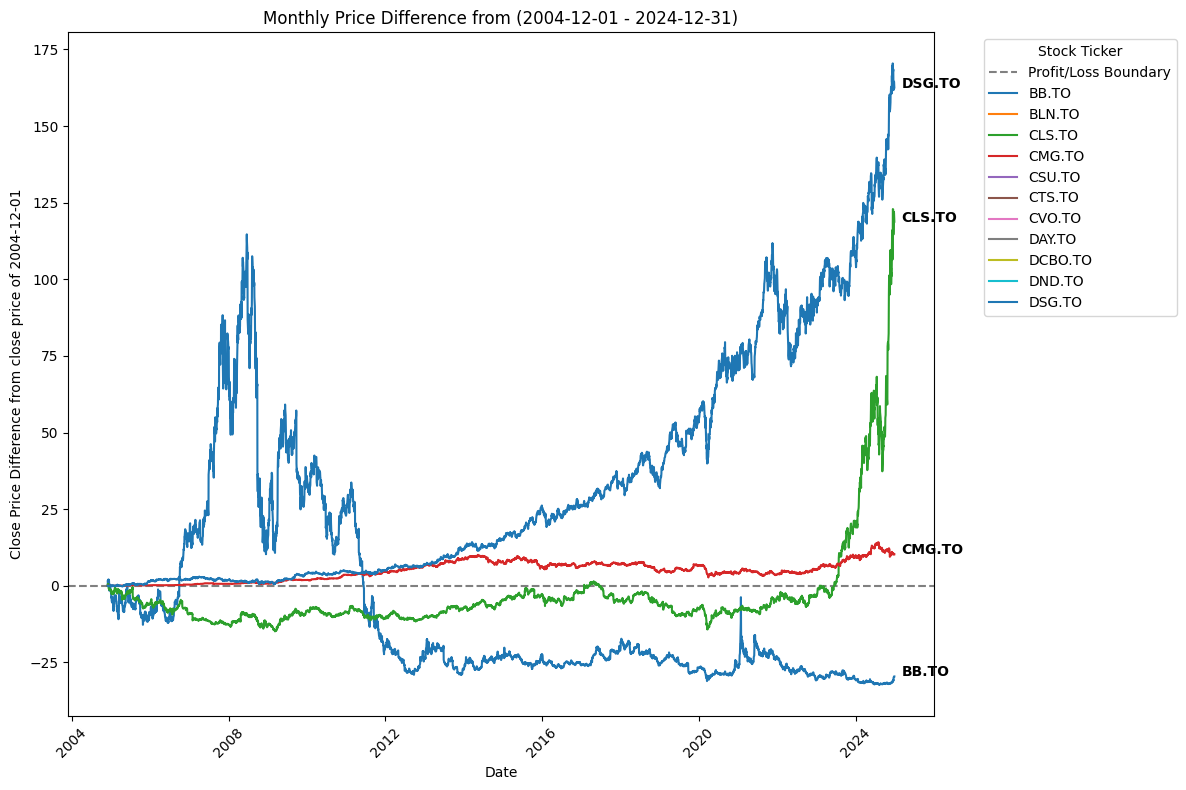

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your dataset
analysis_data = data

# Ensure 'date' is a datetime object
analysis_data['date'] = pd.to_datetime(analysis_data['date'])
analysis_data.sort_values(by='date', inplace=True)

# Merge sector information into the main dataset (if not already present)
# Assuming `ticker_info` contains 'tic', 'sector', and other relevant columns
ticker_info = analysis_data[['tic', 'sector']].drop_duplicates()
print("technology")
# Define the list of tickers
selected_tickers = [
    'BB.TO',
'CSU.TO',
'CLS.TO',
'DSG.TO',
'DND.TO',
'DCBO.TO',
'CTS.TO',
'CMG.TO',
'DAY.TO',
'CVO.TO',
'BLN.TO'


]

# Filter the dataset
analysis_data = analysis_data[analysis_data['tic'].isin(selected_tickers)]

def calculate_price(startdate, enddate):
    # Filter data within the date range
    analysis_data1 = analysis_data[(analysis_data['date'] >= startdate) & (analysis_data['date'] <= enddate)]

    # Extract only the 'close', 'tic', and 'date' columns
    analysis_data1 = analysis_data1[['close', 'tic', 'date']]

    # Get baseline prices for the start date
    baseline_data = analysis_data1[analysis_data1['date'] == startdate]
    baseline_prices = baseline_data.set_index('tic')['close'].to_dict()

    # Debugging: Print baseline prices
    print("Baseline prices:", baseline_prices)

    # Calculate price difference from baseline
    analysis_data1['price_difference'] = analysis_data1['tic'].map(baseline_prices)
    analysis_data1['price_difference'] = analysis_data1['close'] - analysis_data1['price_difference']

    # Plot the line graph
    plt.figure(figsize=(12, 8))

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Profit/Loss Boundary')

    for tic, group in analysis_data1.groupby('tic'):
        # Plot the price difference for each ticker
        plt.plot(group['date'], group['price_difference'], label=tic)
        
        # Annotate the ticker name at the last point of the line
        last_point = group.iloc[-1]
        plt.annotate(
            tic,
            xy=(last_point['date'], last_point['price_difference']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10,
            color='black',
            weight='bold'
        )

    plt.title(f'Monthly Price Difference from ({startdate} - {enddate})')
    plt.xlabel('Date')
    plt.ylabel(f'Close Price Difference from close price of {startdate}')
    plt.xticks(rotation=45)
    plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Test the function with the provided date ranges
calculate_price('2004-12-01', '2024-12-31')


In [ ]:
'CNR.TO',
'CP.TO',
'AC.TO',
'ATRL.TO',
'CAE.TO',
'EFN.TO',
'BLDP.TO',
'ATS.TO',
'ARE.TO',
'CJT.TO',
'BDGI.TO',
'EIF.TO',
'AFN.TO',
'CHR.TO',
'BDT.TO'
